In [68]:
# Sounds like a distopian future novel setting

# LLM As A Judge

##### Sounds distopian

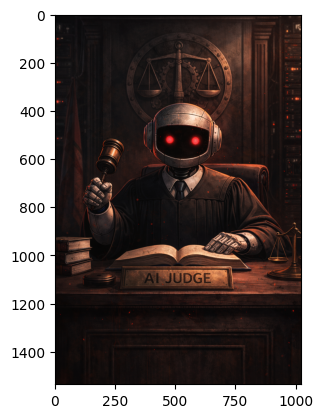

In [4]:
import cv2
import matplotlib.pyplot as plt
image = cv2.imread("LLMJudge.png", cv2.IMREAD_COLOR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
from IPython.display import display, Markdown
display(Markdown("# LLM As A Judge"))
display(Markdown("##### Sounds distopian"))
plt.imshow(image)

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
wa=pd.read_csv("wannoreport2.csv")


In [86]:
andysays={0:"top level throw.  Shoulders level throughout (left to right).  Discus, right shoulder, and gaze are behind the right hip as they rotate to delivery.   Left foot, knee, hip, elbow, and shoulder are forming a block in which the right side pivots around and delivers the discus.  ",
 1:"High level thrower.  Windup Looks nice.  Their left upper body never crosses in front of the left lower body.  Shoulders stay level, right side stays behind right hip. ",
 2:"High level thrower. gifted with speed. Moving a little fast for me, but I didn't see any issues with this one.  ",
 3:'Foot stance is much wider than hips. Athlete upon leaving the wind up immediately looks over left shoulder, which puts the athlete off balance and never winds the spring in the torso properly because of it.  The left side leads the whole way. Discus is also not held at or near shoulder height, dips coming around to sprint and again to release.',
 4:'this is a beautiful man and a beautiful throw.   I did not see much for critique here (dudes an Olympian lol)',
 5:'''When the athlete is winding up to the right, you can see him stand up.  This is due to the athlete not being comfortable using the body's natural lock point by being in a slightly squatted position with both feet forward and rotating the trunk. You can see from the high level videos that the others upper bodies stop at about 90 degrees from where they face out the back. That's a biomechanical spring in your body used to throw the disc and shot. By standing and rotating around that stop, the athlete doesn't set their body up to rotate correctly. You can see after that error in windup, immediately overrates over his left side, left side dragging rest of body instead of right side driving it, 
athlete never sets proper torsion on upper body for delivery.''',
 6:'High level power throw. Athlete winds upper body out and over right leg to set up proper body angles.   Supports with left leg and left side upper body to block.   Explosive rotation and vertical delivery out of the power throw position. '}

In [107]:
realscores={0:8.5,
 1:7,
 2:7,
 3:6,
 4:8.5,
 5:6,
 6:7}

In [109]:
wa['Actual']=wa['Unnamed: 0'].map(realscores)
wa['AbsError']=abs(wa['Actual']-wa['score'])

In [87]:
wa['CoachFeedback']=wa['Unnamed: 0'].map(andysays)

In [113]:
import pandas as pd
import ollama
from pydantic import BaseModel, Field


class CoachJudgeResult(BaseModel):
    score: int = Field(ge=1, le=10)
   

def judge_coach_alignment(
    llm_feedback: str,
    coach_feedback: str,
    model: str = "gemma4:e4b",
    temperature: float = 0.0,
) -> CoachJudgeResult:
    prompt = f"""
You are an expert discus throwing coach and evaluator.

Your job is to compare two pieces of feedback:

1. LLM feedback
2. Real coach feedback

Score how well the LLM feedback aligns with the real coach feedback.

Scoring rubric:
- same_main_points: Does the LLM identify the same major strengths/flaws?


Overall score:
- 9-10: highly aligned
- 7-8: mostly aligned
- 5-6: partially aligned
- 3-4: weak alignment
- 1-2: poor alignment

Important:
- Do not require word-for-word similarity.
- Reward similar coaching points.
- If the LLM says different words but gives the same coaching direction, score it well.
- Penalize made-up flaws

LLM feedback:
{llm_feedback}

Real coach feedback:
{coach_feedback}
"""

    resp = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        format=CoachJudgeResult.model_json_schema(),
        options={"temperature": temperature},
    )

    return CoachJudgeResult.model_validate_json(resp["message"]["content"])

In [117]:
results = []

count=0
for _, row in wa.iterrows():
    
    llm_feedback = str(row["feedback"])
    coach_feedback = str(row["CoachFeedback"])

    judged = judge_coach_alignment(
        llm_feedback=llm_feedback,
        coach_feedback=coach_feedback,
        model="gemma4:e4b",
        temperature=0
    )

    results.append({
        "llm_feedback": llm_feedback,
        "coach_feedback": coach_feedback,
        "overall_score": judged.score
    })
    count+=1
    print(count)

results_df = pd.DataFrame(results)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [127]:
pd.concat([results_df,wa],axis=1).\
    groupby(['model','frames','prompt'])['overall_score'].median().\
    sort_values(ascending=False)

model         frames  prompt               
gemma3:12b    12      \nYou are a brutally     3.0
llava:7b      15      \nYou are a brutally     3.0
gemma4:e4b    18      \nYou are a discus co    3.0
                      \nYou are an AI sport    3.0
                      \nYou are an elite Ol    3.0
gemma3:12b    12      \nYou are a discus co    3.0
llava:7b      12      \nYou are a discus co    3.0
                      \nYou are an AI sport    3.0
                      \nYou are an elite Ol    3.0
              15      \nYou are a discus co    3.0
gemma4:e4b    15      \nYou are an elite Ol    3.0
llava:7b      15      \nYou are an AI sport    3.0
                      \nYou are an elite Ol    3.0
              18      \nYou are a brutally     3.0
                      \nYou are an AI sport    3.0
                      \nYou are an elite Ol    3.0
qwen2.5vl:7b  12      \nYou are a brutally     3.0
                      \nYou are a discus co    3.0
gemma4:e4b    18      \nYou are a brut

In [131]:
pd.concat([results_df,wa],axis=1).\
    groupby(['frames','model','prompt','Actual'])['overall_score'].median().\
    sort_values(ascending=False)

frames  model         prompt                 Actual
18      llava:7b      \nYou are an elite Ol  8.5       8.5
        gemma3:12b    \nYou are an elite Ol  8.5       8.5
15      llava:7b      \nYou are an elite Ol  8.5       6.0
12      gemma3:12b    \nYou are an elite Ol  8.5       6.0
        llava:7b      \nYou are an elite Ol  8.5       6.0
                                                      ... 
15      qwen2.5vl:7b  \nYou are an AI sport  7.0       1.0
                                             6.0       1.0
18      llava:7b      \nYou are a discus co  6.0       1.0
15      qwen2.5vl:7b  \nYou are a brutally   7.0       1.0
                                             6.0       1.0
Name: overall_score, Length: 144, dtype: float64